# **IMPORTING NECESSARY LIABRARIES**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler , LabelEncoder , OneHotEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error , accuracy_score,r2_score,mean_absolute_error

In [49]:
psx=pd.read_excel(r"C:\Users\MEMON ENTERPRISES\Desktop\Pakistan_Stock_Exchange.xlsx")
psx.head(20)

,S.NO,Price,Sector,Company Name,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,...,Book Value,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend
0,0,70.01,COMMERCIAL BANKS,Allied Bank Ltd.,15.23,8.60,18.51,3.78,2.30,64.56,...,119.34,135.81,0.59,0.52,16.58,22.43,5.68,0.94,8.5,13.99
1,1,345.50,PHARMACEUTICALS,Abbott Laboratories (Pak) Ltd.,-8.17,-5.93,30.69,11.26,NaN,-153.24,...,167.94,159.59,2.06,2.16,17.56,-10.24,50.43,8.86,15.0,15.00
2,2,86.49,CEMENT,Attock Cement Pakistan Ltd.,11.03,3.34,8.16,10.60,7.84,35.17,...,133.47,139.77,0.65,0.62,6.41,7.89,44.57,2.86,3.5,6.00
3,3,34.00,SUGAR & ALLIED INDUSTRIES,Adam Sugar Mills Ltd.,2.51,-1.16,8.18,4.16,10.16,-59.09,...,303.09,305.41,0.11,0.11,3.65,1.10,56.59,2.06,2.5,1.50
4,4,53.43,TEXTILE COMPOSITE,Artistic Denim Mills Ltd.,12.63,2.90,7.79,6.86,4.23,62.13,...,93.92,103.31,0.57,0.52,9.04,12.23,36.05,3.26,2.0,3.50
5,5,10.27,ENGINEERING,Agha Steel Industries Ltd,1.50,0.33,3.07,3.35,6.85,-51.14,...,27.06,28.56,0.38,0.36,11.84,5.25,37.77,4.47,NaN,NaN
6,6,14.25,INSURANCE,Askari General Insurance Company. Ltd.,2.28,1.11,4.82,2.96,3.13,-5.39,...,33.69,35.51,0.42,0.40,14.08,12.84,35.15,4.95,2.9,2.90
7,7,66.10,AUTOMOBILE PARTS & ACCESSORIES,Agriautos Industries Ltd.,-1.23,1.57,-1.23,NaN,NaN,-203.52,...,124.36,123.13,0.53,0.54,-0.99,-1.00,70.32,-0.70,NaN,NaN
8,8,8.56,CHEMICAL,Agritech Ltd.,-4.87,-4.87,-7.53,NaN,NaN,-158.70,...,25.66,6.18,0.33,1.39,-24.64,-315.21,14.71,-3.63,NaN,NaN
9,9,49.26,PHARMACEUTICALS,AGP Ltd.,1.59,0.43,5.10,9.66,15.49,-37.65,...,36.10,38.03,1.36,1.30,13.97,8.36,79.69,11.13,2.0,2.00


# **DATA PREPROCESSING**

In [51]:
psx.drop("S.NO", axis=1, inplace=True)
psx.head()

,Price,Sector,Company Name,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,Price Earning Growth,Book Value,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend
0,70.01,COMMERCIAL BANKS,Allied Bank Ltd.,15.23,8.60,18.51,3.78,2.30,64.56,0.04,119.34,135.81,0.59,0.52,16.58,22.43,5.68,0.94,8.5,13.99
1,345.50,PHARMACEUTICALS,Abbott Laboratories (Pak) Ltd.,-8.17,-5.93,30.69,11.26,NaN,-153.24,NaN,167.94,159.59,2.06,2.16,17.56,-10.24,50.43,8.86,15.0,15.00
2,86.49,CEMENT,Attock Cement Pakistan Ltd.,11.03,3.34,8.16,10.60,7.84,35.17,0.22,133.47,139.77,0.65,0.62,6.41,7.89,44.57,2.86,3.5,6.00
3,34.00,SUGAR & ALLIED INDUSTRIES,Adam Sugar Mills Ltd.,2.51,-1.16,8.18,4.16,10.16,-59.09,-0.17,303.09,305.41,0.11,0.11,3.65,1.10,56.59,2.06,2.5,1.50
4,53.43,TEXTILE COMPOSITE,Artistic Denim Mills Ltd.,12.63,2.90,7.79,6.86,4.23,62.13,0.07,93.92,103.31,0.57,0.52,9.04,12.23,36.05,3.26,2.0,3.50


In [52]:
psx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Price                         316 non-null    float64
 1   Sector                        316 non-null    object 
 2   Company Name                  316 non-null    object 
 3   Latest EPS                    291 non-null    float64
 4   EPS Last Quarter              291 non-null    float64
 5   Last Annual EPS               290 non-null    float64
 6   Price to Earning Ratio        241 non-null    float64
 7   Expected Price to Earning     215 non-null    float64
 8   Expected Earning Growth       290 non-null    float64
 9   Price Earning Growth          210 non-null    float64
 10  Book Value                    291 non-null    float64
 11  Expected Book Value           291 non-null    float64
 12  Price to Book Value           291 non-null    float64
 13  Expec

In [53]:
psx.shape

(316, 20)

In [54]:
psx.duplicated().sum()

0

In [55]:
psx.isna().sum()

Price                             0
Sector                            0
Company Name                      0
Latest EPS                       25
EPS Last Quarter                 25
Last Annual EPS                  26
Price to Earning Ratio           75
Expected Price to Earning       101
Expected Earning Growth          26
Price Earning Growth            106
Book Value                       25
Expected Book Value              25
Price to Book Value              25
Expected Price to Book Value     25
Return on Equity                 26
Expected Return on Equity        25
Equity to Asset Ratio            26
Return on Assets                 26
Last Annual Dividend            166
Expected Dividend               166
dtype: int64

In [56]:
psx.fillna({
    'Latest EPS': psx['Latest EPS'].ffill(),
    'EPS Last Quarter': psx['EPS Last Quarter'].ffill(),
    'Last Annual EPS': psx['Last Annual EPS'].ffill(),
    'Price to Earning Ratio': psx['Price to Earning Ratio'].ffill(),
    'Expected Price to Earning': psx['Expected Price to Earning'].median(),
    'Expected Earning Growth': psx['Expected Earning Growth'].median(),
    'Price Earning Growth': psx['Price Earning Growth'].ffill(),
    'Book Value': psx['Book Value'].ffill(),
    'Expected Book Value': psx['Expected Book Value'].median(),
    'Price to Book Value': psx['Price to Book Value'].ffill(),
    'Expected Price to Book Value': psx['Expected Price to Book Value'].median(),
    'Return on Equity': psx['Return on Equity'].ffill(),
    'Expected Return on Equity': psx['Expected Return on Equity'].median(),
    'Equity to Asset Ratio': psx['Equity to Asset Ratio'].ffill(),
    'Return on Assets': psx['Return on Assets'].ffill(),
    'Last Annual Dividend': 0,
    'Expected Dividend': 0
     },inplace=True)
psx.head(20)

,Price,Sector,Company Name,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,Price Earning Growth,Book Value,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend
0,70.01,COMMERCIAL BANKS,Allied Bank Ltd.,15.23,8.60,18.51,3.78,2.30,64.56,0.04,119.34,135.81,0.59,0.52,16.58,22.43,5.68,0.94,8.5,13.99
1,345.50,PHARMACEUTICALS,Abbott Laboratories (Pak) Ltd.,-8.17,-5.93,30.69,11.26,5.20,-153.24,0.04,167.94,159.59,2.06,2.16,17.56,-10.24,50.43,8.86,15.0,15.00
2,86.49,CEMENT,Attock Cement Pakistan Ltd.,11.03,3.34,8.16,10.60,7.84,35.17,0.22,133.47,139.77,0.65,0.62,6.41,7.89,44.57,2.86,3.5,6.00
3,34.00,SUGAR & ALLIED INDUSTRIES,Adam Sugar Mills Ltd.,2.51,-1.16,8.18,4.16,10.16,-59.09,-0.17,303.09,305.41,0.11,0.11,3.65,1.10,56.59,2.06,2.5,1.50
4,53.43,TEXTILE COMPOSITE,Artistic Denim Mills Ltd.,12.63,2.90,7.79,6.86,4.23,62.13,0.07,93.92,103.31,0.57,0.52,9.04,12.23,36.05,3.26,2.0,3.50
5,10.27,ENGINEERING,Agha Steel Industries Ltd,1.50,0.33,3.07,3.35,6.85,-51.14,-0.13,27.06,28.56,0.38,0.36,11.84,5.25,37.77,4.47,0.0,0.00
6,14.25,INSURANCE,Askari General Insurance Company. Ltd.,2.28,1.11,4.82,2.96,3.13,-5.39,-0.58,33.69,35.51,0.42,0.40,14.08,12.84,35.15,4.95,2.9,2.90
7,66.10,AUTOMOBILE PARTS & ACCESSORIES,Agriautos Industries Ltd.,-1.23,1.57,-1.23,2.96,5.20,-203.52,-0.58,124.36,123.13,0.53,0.54,-0.99,-1.00,70.32,-0.70,0.0,0.00
8,8.56,CHEMICAL,Agritech Ltd.,-4.87,-4.87,-7.53,2.96,5.20,-158.70,-0.58,25.66,6.18,0.33,1.39,-24.64,-315.21,14.71,-3.63,0.0,0.00
9,49.26,PHARMACEUTICALS,AGP Ltd.,1.59,0.43,5.10,9.66,15.49,-37.65,-0.41,36.10,38.03,1.36,1.30,13.97,8.36,79.69,11.13,2.0,2.00


In [57]:
psx.isna().sum()

Price                           0
Sector                          0
Company Name                    0
Latest EPS                      0
EPS Last Quarter                0
Last Annual EPS                 0
Price to Earning Ratio          0
Expected Price to Earning       0
Expected Earning Growth         0
Price Earning Growth            0
Book Value                      0
Expected Book Value             0
Price to Book Value             0
Expected Price to Book Value    0
Return on Equity                0
Expected Return on Equity       0
Equity to Asset Ratio           0
Return on Assets                0
Last Annual Dividend            0
Expected Dividend               0
dtype: int64

In [58]:
psx.describe()

,Price,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,Price Earning Growth,Book Value,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend
count,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000
mean,174.437943,19.899525,5.819589,27.267057,12.338797,9.355348,-51.744557,-0.383703,136.193766,146.844462,1.177437,0.732405,26.215886,16.769367,41.784589,2.785538,7.343987,9.935981
std,1229.177014,70.729858,23.336276,104.906666,38.894513,33.954181,1580.663784,3.274420,282.017458,339.551896,2.963745,5.210325,287.010513,80.899644,74.937640,33.801473,28.479890,40.797422
min,0.680000,-117.580000,-47.590000,-77.000000,0.520000,0.700000,-25646.670000,-48.970000,-112.290000,-218.850000,-12.020000,-79.410000,-833.150000,-315.210000,-613.320000,-539.380000,0.000000,0.000000
25%,7.985000,-0.062500,-0.122500,0.800000,3.372500,3.280000,-49.020000,-0.220000,16.440000,19.120000,0.330000,0.317500,3.645000,2.167500,31.075000,0.947500,0.000000,0.000000
50%,22.885000,2.705000,0.570000,4.505000,5.410000,5.200000,4.430000,0.020000,40.360000,44.350000,0.565000,0.530000,10.560000,9.240000,43.920000,3.790000,0.000000,0.000000
75%,88.097500,13.532500,4.002500,17.062500,8.420000,6.472500,64.712500,0.090000,134.480000,136.370000,0.992500,0.870000,19.242500,20.600000,60.697500,8.730000,4.625000,5.962500
max,20550.000000,814.680000,287.780000,1248.430000,578.330000,576.000000,9829.410000,6.390000,3386.770000,3818.480000,29.040000,28.690000,4967.780000,1176.470000,826.480000,156.920000,335.000000,489.080000


In [59]:
numeric_cols = psx.select_dtypes(include=['float64','int64']).columns
print("Numeric Columns:", numeric_cols.tolist())

Numeric Columns: ['Price', 'Latest EPS', 'EPS Last Quarter', 'Last Annual EPS', 'Price to Earning Ratio', 'Expected Price to Earning', 'Expected Earning Growth', 'Price Earning Growth', 'Book Value', 'Expected Book Value', 'Price to Book Value', 'Expected Price to Book Value', 'Return on Equity', 'Expected Return on Equity', 'Equity to Asset Ratio', 'Return on Assets', 'Last Annual Dividend', 'Expected Dividend']


In [60]:
for col in numeric_cols:
    Q1 = psx[col].quantile(0.25)
    Q3 = psx[col].quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    outliers = psx[(psx[col] < lb) | (psx[col] > ub)][['Company Name', col]]
    print(f" \nOUTLIERS IN COLUMN: {col}\n")
    if outliers.empty:
        print("No outliers found.")
    else:
        print(outliers)

 
OUTLIERS IN COLUMN: Price

                                          Company Name     Price
1                       Abbott Laboratories (Pak) Ltd.    345.50
11                              AL-Ghazi Tractors Ltd.    257.51
20                               Attock Petroleum Ltd.    291.42
22                              Archroma Pakistan Ltd.    440.00
28                                  Atlas Battery Ltd.    234.55
30                                    Atlas Honda Ltd.    268.70
31                                Attock Refinery Ltd.    254.54
39                          Bhanero Textile Mills Ltd.    930.00
54                        Colgate Palmolive (Pak) Ltd.   1353.35
78                 Engro Corporation Ltd. Consolidated    240.14
82                                 Exide Pakistan Ltd.    328.43
121                         Highnoon Laboratories Ltd.    379.91
137                           Indus Motor Company Ltd.    895.00
140                             Ismail Industries Ltd.    650

In [61]:
real_columns=["Price", "Price Earning Growth", "Book Value", "Expected Book Value", "Price to Book Value", "Expected Price to Book Value"]
columns_to_cap = [
   "Latest EPS",
    "EPS Last Quarter",
    "Last Annual EPS",
    "Expected Earning Growth",
    "Return on Equity",
    "Expected Return on Equity",
    "Equity to Asset Ratio",
    "Return on Assets",
    "Last Annual Dividend",
    "Expected Dividend",
    "Price to Earning Ratio",
    "Expected Price to Earning"
]
for col in columns_to_cap:
    Q1 = psx[col].quantile(0.25)
    Q3 = psx[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    psx[col] = np.where(psx[col] > upper, upper,np.where(psx[col] < lower, lower, psx[col]))
psx.head()

,Price,Sector,Company Name,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,Price Earning Growth,Book Value,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend
0,70.01,COMMERCIAL BANKS,Allied Bank Ltd.,15.23,8.60,18.51,3.78,2.30,64.56,0.04,119.34,135.81,0.59,0.52,16.58,22.43,5.68,0.94,8.5000,13.99000
1,345.50,PHARMACEUTICALS,Abbott Laboratories (Pak) Ltd.,-8.17,-5.93,30.69,11.26,5.20,-153.24,0.04,167.94,159.59,2.06,2.16,17.56,-10.24,50.43,8.86,11.5625,14.90625
2,86.49,CEMENT,Attock Cement Pakistan Ltd.,11.03,3.34,8.16,10.60,7.84,35.17,0.22,133.47,139.77,0.65,0.62,6.41,7.89,44.57,2.86,3.5000,6.00000
3,34.00,SUGAR & ALLIED INDUSTRIES,Adam Sugar Mills Ltd.,2.51,-1.16,8.18,4.16,10.16,-59.09,-0.17,303.09,305.41,0.11,0.11,3.65,1.10,56.59,2.06,2.5000,1.50000
4,53.43,TEXTILE COMPOSITE,Artistic Denim Mills Ltd.,12.63,2.90,7.79,6.86,4.23,62.13,0.07,93.92,103.31,0.57,0.52,9.04,12.23,36.05,3.26,2.0000,3.50000


In [62]:
for col in numeric_cols:
    if col in real_columns:
        continue
    else:
        Q1 = psx[col].quantile(0.25)
        Q3 = psx[col].quantile(0.75)
        IQR = Q3 - Q1
        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR
        outliers = psx[(psx[col] < lb) | (psx[col] > ub)][['Company Name', col]]        
        print(f" \nOUTLIERS IN COLUMN: {col}\n")
        if outliers.empty:
            print("No outliers found.")
        else:
            print(outliers)

 
OUTLIERS IN COLUMN: Latest EPS

No outliers found.
 
OUTLIERS IN COLUMN: EPS Last Quarter

No outliers found.
 
OUTLIERS IN COLUMN: Last Annual EPS

No outliers found.
 
OUTLIERS IN COLUMN: Price to Earning Ratio

No outliers found.
 
OUTLIERS IN COLUMN: Expected Price to Earning

No outliers found.
 
OUTLIERS IN COLUMN: Expected Earning Growth

No outliers found.
 
OUTLIERS IN COLUMN: Return on Equity

No outliers found.
 
OUTLIERS IN COLUMN: Expected Return on Equity

No outliers found.
 
OUTLIERS IN COLUMN: Equity to Asset Ratio

No outliers found.
 
OUTLIERS IN COLUMN: Return on Assets

No outliers found.
 
OUTLIERS IN COLUMN: Last Annual Dividend

No outliers found.
 
OUTLIERS IN COLUMN: Expected Dividend

No outliers found.


# **Exploratory Data Analysis**

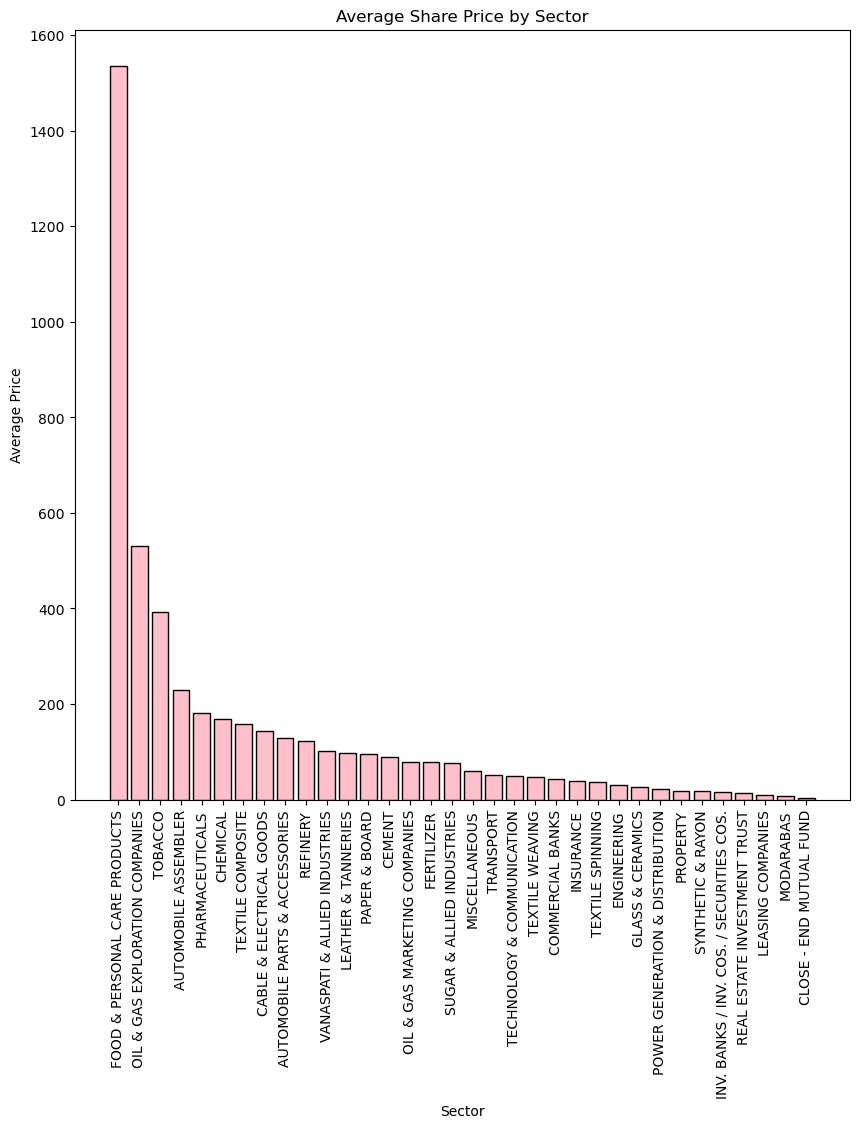

In [64]:
sector_avg_price = psx.groupby('Sector')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,10))
plt.bar(sector_avg_price.index, sector_avg_price.values, color='pink', edgecolor='black')
plt.title('Average Share Price by Sector')
plt.xlabel('Sector')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()


In [65]:
sector_avg_price

Sector
FOOD & PERSONAL CARE PRODUCTS               1534.644737
OIL & GAS EXPLORATION COMPANIES              530.097500
TOBACCO                                      392.850000
AUTOMOBILE ASSEMBLER                         229.946364
PHARMACEUTICALS                              181.832727
CHEMICAL                                     169.603500
TEXTILE COMPOSITE                            157.460000
CABLE & ELECTRICAL GOODS                     143.216667
AUTOMOBILE PARTS & ACCESSORIES               129.495714
REFINERY                                     122.780000
VANASPATI & ALLIED INDUSTRIES                101.410000
LEATHER & TANNERIES                           96.800000
PAPER & BOARD                                 94.696667
CEMENT                                        89.260000
OIL & GAS MARKETING COMPANIES                 79.695000
FERTILIZER                                    79.485000
SUGAR & ALLIED INDUSTRIES                     76.392000
MISCELLANEOUS                            

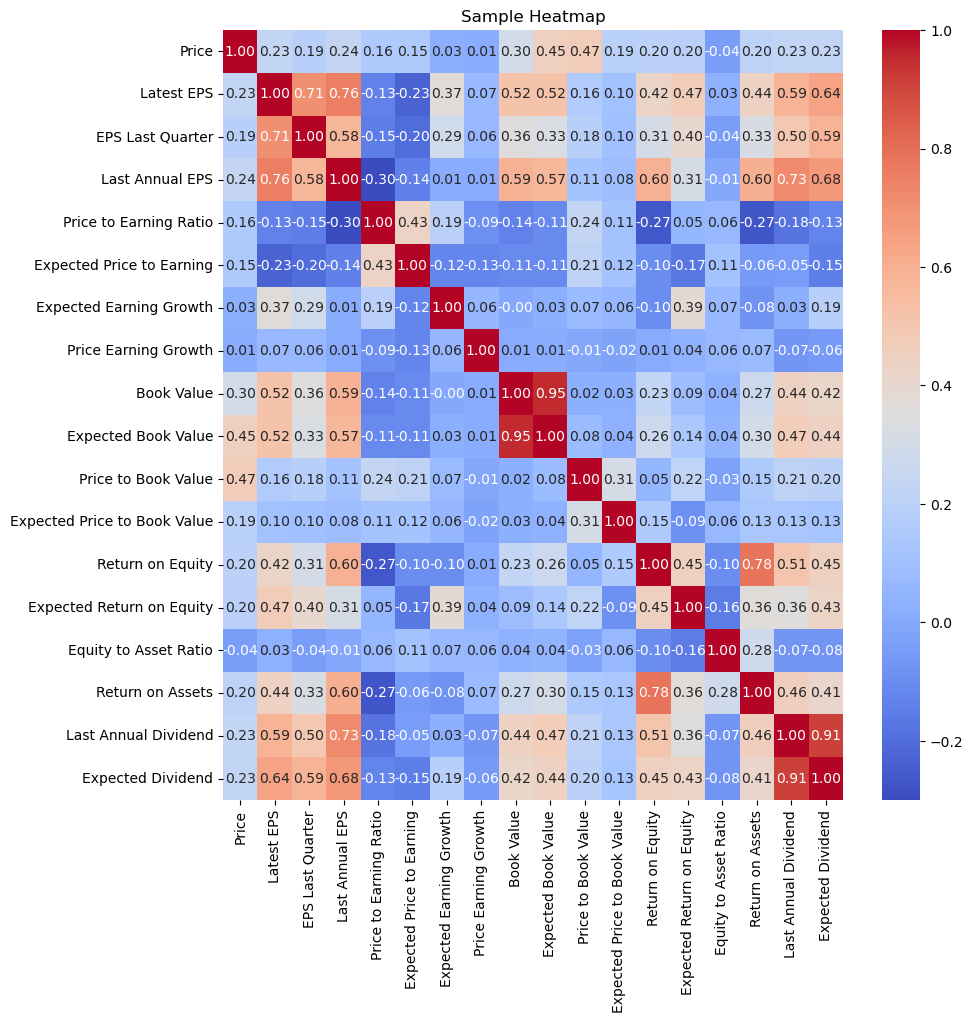

In [66]:
numeric_df = psx.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(10,10))
sb.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")  # annot=True numbers show karega
plt.title('Sample Heatmap')
plt.show()

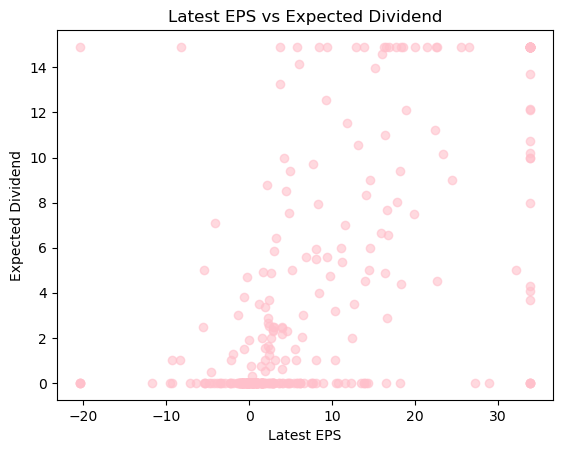

In [67]:
plt.scatter(psx['Latest EPS'], psx['Expected Dividend'], color='pink', alpha=0.6)
plt.title('Latest EPS vs Expected Dividend')
plt.xlabel('Latest EPS')
plt.ylabel('Expected Dividend')
plt.show()

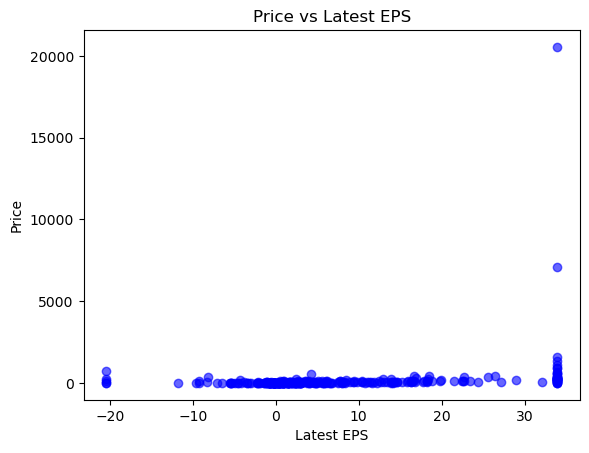

In [68]:
#plt.figure(figsize=(8,5))
plt.scatter(psx['Latest EPS'], psx['Price'], color='blue', alpha=0.6)
plt.title('Price vs Latest EPS')
plt.xlabel('Latest EPS')
plt.ylabel('Price')
plt.show()


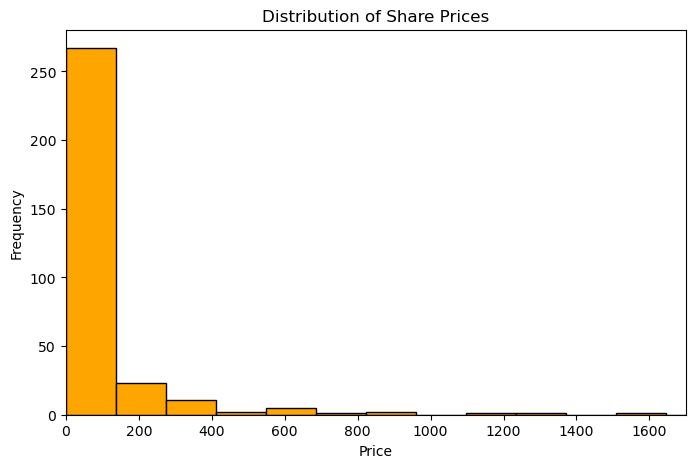

In [69]:
plt.figure(figsize=(8,5))
#plt.hist(psx['Price'], bins=30, color='orange', edgecolor='black')
plt.hist(psx['Price'], bins=150, color='orange', edgecolor='black')
plt.xlim(0,1700)
plt.title('Distribution of Share Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


# **Model : ROE Prediction**

In [71]:
company_encoder=LabelEncoder()
psx["company_encoded"]=company_encoder.fit_transform(psx["Company Name"])

In [72]:
psx.sample()

,Price,Sector,Company Name,Latest EPS,EPS Last Quarter,Last Annual EPS,Price to Earning Ratio,Expected Price to Earning,Expected Earning Growth,Price Earning Growth,...,Expected Book Value,Price to Book Value,Expected Price to Book Value,Return on Equity,Expected Return on Equity,Equity to Asset Ratio,Return on Assets,Last Annual Dividend,Expected Dividend,company_encoded
193,4.25,INV. BANKS / INV. COS. / SECURITIES COS.,Next Capital Ltd.,-1.05,-0.14,0.54,7.87,5.2,-219.61875,0.13,...,7.38,0.48,0.58,5.86,-18.97,45.65,2.68,0.0,0.0,190


In [73]:
x=psx[['company_encoded','Last Annual EPS','Return on Assets','Last Annual Dividend','Expected Dividend','Expected Return on Equity','Latest EPS']]
y=psx['Return on Equity']

In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=40)

In [75]:
scale=StandardScaler()

In [76]:
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.fit_transform(x_test)

In [77]:
model=RandomForestRegressor()
model.fit(x_train_scaled,y_train)

RandomForestRegressor()

In [78]:
y_pred=model.predict(x_test_scaled)

In [79]:
y_pred

array([ 1.93809000e+01, -1.10455000e+00,  6.50226250e+00,  1.56350000e+01,
       -1.74505000e+00, -5.66733750e+00, -9.75417500e+00,  1.65680000e+00,
        2.39680000e+01,  1.91821000e+01,  4.50317500e+00,  9.43210000e+00,
        5.98880000e+00,  4.22258750e+00,  3.19160375e+01,  3.84566250e+00,
        1.85046000e+01,  3.42406250e+00, -2.87341250e+00,  6.91538750e+00,
        4.33462500e-01,  1.06006000e+01,  3.69205625e+01,  3.18537500e+01,
       -2.87566250e+00,  2.10293000e+01,  6.83210000e+00,  5.32238750e+00,
       -2.60957500e+00,  2.30122000e+01,  1.10708000e+01,  3.53450000e+00,
        3.13527500e+00,  4.50890000e+00,  4.84187500e-01,  6.93755000e+00,
        4.51037500e+00,  6.15720000e+00,  2.71229125e+01, -4.94690000e+00,
        4.25835000e+00,  1.95544000e+01,  6.78980000e+00,  2.21356875e+01,
        1.39694000e+01,  2.37282625e+01, -7.05463750e+00,  1.14242500e+00,
        9.15690000e+00,  1.29610000e+01, -1.05393375e+01,  7.12783750e+00,
        1.56089000e+01,  

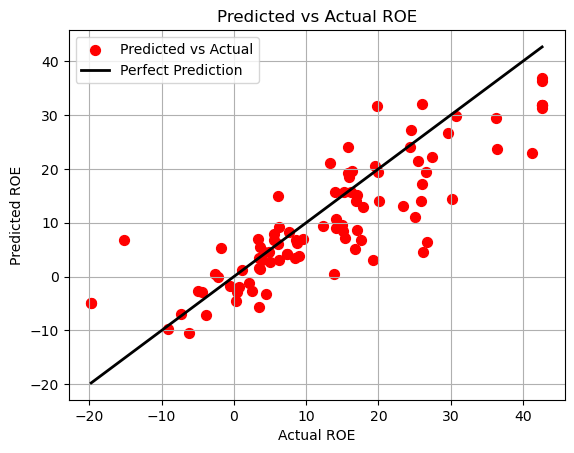

In [80]:
plt.scatter(y_test, y_pred, color='red', s=50, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='black', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ROE')
plt.ylabel('Predicted ROE')
plt.title('Predicted vs Actual ROE')
plt.legend()
plt.grid(True)


In [81]:
print("R²:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
mse=mean_squared_error(y_test,y_pred)
print("RMSE:",np.sqrt(mse ))

R²: 0.6934096930713124
MAE: 5.769335657894737
RMSE: 7.746196078047017


In [82]:
model_2=KNeighborsRegressor(n_neighbors=5)

In [83]:
model_2.fit(x_train_scaled,y_train)

KNeighborsRegressor()

In [84]:
y_pred_2=model_2.predict(x_test_scaled)

In [85]:
y_pred_2

array([ 20.988  ,   0.528  ,  15.888  ,  15.496  ,   4.81   ,  -1.82   ,
        -4.942  ,   4.348  ,  24.746  ,  12.364  ,  12.05   ,  12.978  ,
         8.14   ,   7.078  ,  22.84775,   4.676  ,  11.876  ,   3.442  ,
        -1.496  ,   6.384  ,   1.64175,   9.25   ,  30.3315 ,  29.65975,
        -8.96825,  31.42175,  10.626  ,   4.5    ,  -3.786  ,  16.406  ,
        21.13   ,   4.41   ,   4.29   ,  11.246  ,  -0.318  ,   3.476  ,
         8.92   ,   3.812  ,  15.856  , -15.64875,   4.676  ,  17.068  ,
         9.438  ,  22.86775,  10.398  ,  23.32775,  -9.7225 ,   1.63   ,
         4.124  ,  11.19   ,  -0.03225,  18.592  ,  14.746  ,  14.06   ,
        29.70575,  14.818  ,   0.4355 ,  13.63   ,  29.66375,   6.278  ,
         0.45   ,   2.178  ,  27.7    ,   9.714  ,  14.998  ,   6.242  ,
        10.346  ,  15.836  ,  -3.786  ,  -3.266  ,  -2.942  ,  -3.518  ,
        19.206  ,  21.312  ,  28.3395 ,   4.208  ,  32.09375,  21.19   ,
        25.31975,  11.49   ,   6.054  ,   8.694  , 

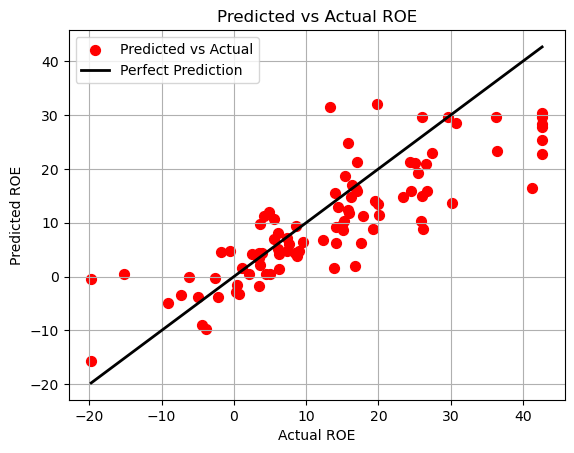

In [86]:
plt.scatter(y_test, y_pred_2, color='red', s=50, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='black', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ROE')
plt.ylabel('Predicted ROE')
plt.title('Predicted vs Actual ROE')
plt.legend()
plt.grid(True)

In [87]:
print("R²:",r2_score(y_test,y_pred_2))
print("MAE:",mean_absolute_error(y_test,y_pred_2))
print("MSE:",mean_squared_error(y_test,y_pred_2))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_2)))

R²: 0.6532311123870094
MAE: 6.252860526315788
MSE: 67.86700392039475
RMSE: 8.23814323257339


In [88]:
model_3=LinearRegression()
model_3.fit(x_train_scaled,y_train)

LinearRegression()

In [89]:
y_pred_3=model_3.predict(x_test_scaled)

In [90]:
y_pred_3

array([ 25.29571227,   1.53881247,  11.6389173 ,  15.892877  ,
       -11.10780041,  -2.40493337,  -5.43791533,   2.58583703,
        15.86390122,  13.56702376,   1.35431109,  13.82115525,
         7.30945532,   5.48960664,  34.12700764,   3.8356905 ,
        17.12585702,   5.0255532 ,  -0.73361139,  10.16053506,
        -2.11005614,   9.93804051,  39.97804788,  28.59044272,
        -5.60949601,  27.23851558,   7.15986202,   7.83552508,
        -0.63955758,  23.95439294,  20.8192048 ,   6.30001873,
         4.29131472,   4.97262275,  -0.2343797 ,   3.07667152,
         7.50748863,   3.35018808,  23.6304459 , -13.70247407,
         1.26131601,  20.13199248,   6.52992394,  27.25154801,
        11.85683711,  28.08532524,  -2.72922192,   3.22276275,
         4.57390673,  11.29152405,  -8.74772402,  11.13673608,
        15.59200094,  17.97356702,  28.28439259,  19.03486443,
       -13.39825331,  20.31516565,  31.08063624,   1.47224617,
         2.68775558,   3.00468143,  31.74693746,   4.83

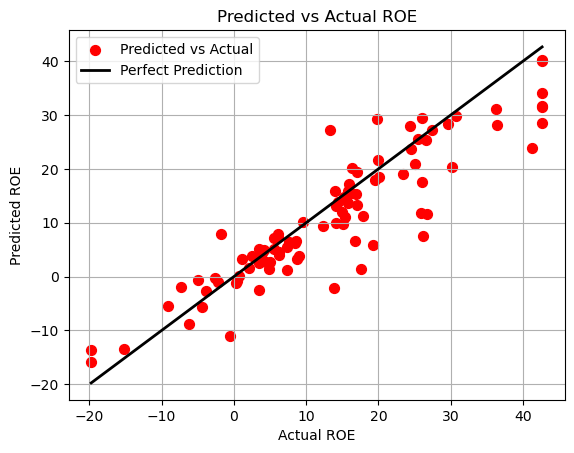

In [91]:
plt.scatter(y_test, y_pred_3, color='red', s=50, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='black', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ROE')
plt.ylabel('Predicted ROE')
plt.title('Predicted vs Actual ROE')
plt.legend()
plt.grid(True)

In [92]:
print("R²:",r2_score(y_test,y_pred_3))
print("MAE:",mean_absolute_error(y_test,y_pred_3))
print("MSE:",mean_squared_error(y_test,y_pred_3))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_3)))

R²: 0.8002707135556159
MAE: 4.313389244832215
MSE: 39.08951682328166
RMSE: 6.252160972278438


In [105]:
model_4=DecisionTreeRegressor()
model_4.fit(x_train_scaled,y_train)

DecisionTreeRegressor()

In [107]:
y_pred_4=model_4.predict(x_test_scaled)

In [109]:
y_pred_4

array([ 15.63   ,  -4.98   ,  17.94   ,  14.     ,  -4.63   ,  -4.63   ,
       -19.75125,   2.77   ,  17.88   ,  24.52   ,   2.77   ,   8.16   ,
         5.41   ,   3.65   ,  22.76   ,   6.7    ,  12.31   ,   6.7    ,
        -2.43   ,   8.53   ,   8.17   ,   9.04   ,  42.63875,  33.05   ,
       -19.75125,  14.95   ,  10.25   ,   5.86   ,   1.43   ,  25.06   ,
        12.43   ,   2.74   ,   6.7    ,   2.43   ,  -3.58   ,  42.63875,
         2.77   ,  11.84   ,  42.63875,  23.6    ,  42.63875,  11.67   ,
         6.41   ,  13.33   ,  19.14   ,  19.72   ,  -3.58   ,  -3.58   ,
         9.72   ,  11.7    ,  -9.63   ,  17.94   ,  17.78   ,  25.06   ,
        21.36   ,  13.21   ,  14.98   ,  12.68   ,  26.76   ,   9.26   ,
        -4.98   ,   2.77   ,  26.76   ,  19.18   ,  12.31   ,   7.17   ,
        17.78   ,   7.74   ,  -4.54   ,  -4.63   ,  -4.63   , -19.75125,
        13.33   ,  24.35   ,  42.63875,  -1.03   ,  39.27   ,  19.14   ,
        31.64   ,  18.2    ,  16.65   ,  10.18   , 

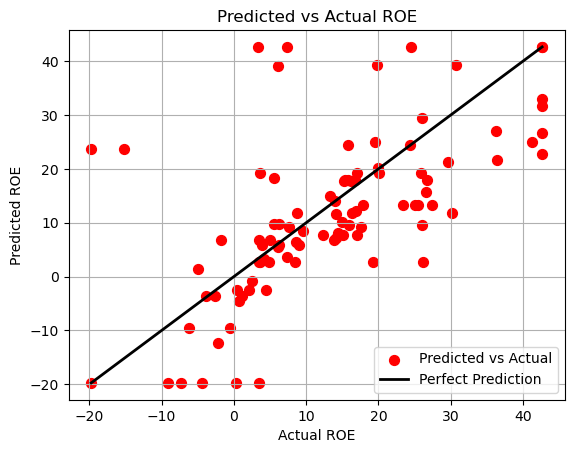

In [96]:
plt.scatter(y_test, y_pred_4, color='red', s=50, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='black', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ROE')
plt.ylabel('Predicted ROE')
plt.title('Predicted vs Actual ROE')
plt.legend()
plt.grid(True)

In [111]:
print("R²:",r2_score(y_test,y_pred_4))
print("MAE:",mean_absolute_error(y_test,y_pred_4))
print("MSE:",mean_squared_error(y_test,y_pred_4))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_4)))

R²: 0.28292606115129526
MAE: 8.130802631578948
MSE: 140.3403291282895
RMSE: 11.846532367249477


In [113]:
model_5=GradientBoostingRegressor()
model_5.fit(x_train_scaled,y_train)

GradientBoostingRegressor()

In [115]:
y_pred_5=model_5.predict(x_test_scaled)

In [117]:
y_pred_5

array([ 20.38652255,  -2.46904522,  -0.84021021,  24.04957011,
        -7.99064914,  -4.33841013,   9.98113738,   1.96096118,
        21.82127978,  19.60434234,   2.1914604 ,  12.54806647,
         6.66520243,   4.64016805,  34.96226146,   5.43954824,
        18.43727398,   4.74624249,  -6.13461864,   7.94903071,
         1.48104915,   9.08858489,  32.05147186,  30.43658276,
        29.32169767,  20.17583832,   8.70050593,   5.79816865,
        15.97030978,  22.04427078,  14.3065775 ,   5.46989455,
         5.2932061 ,   3.56691526,  16.40745656,  11.01936878,
         4.93763066,   9.45414709,  29.58259144,   8.79730554,
         0.14975628,  19.43170045,   7.63086282,  19.95986316,
        13.55515035,  19.7748509 ,  11.84085139,  -0.13282742,
         6.21249232,  13.96069614,  -7.93657212,   2.04062462,
        14.94943941,  22.39394075,  25.69320852,  11.65484993,
        11.23159667,  15.95284658,  28.60409563,   7.8693144 ,
        -3.42266682,  -3.13222307,  37.12074044,   9.30

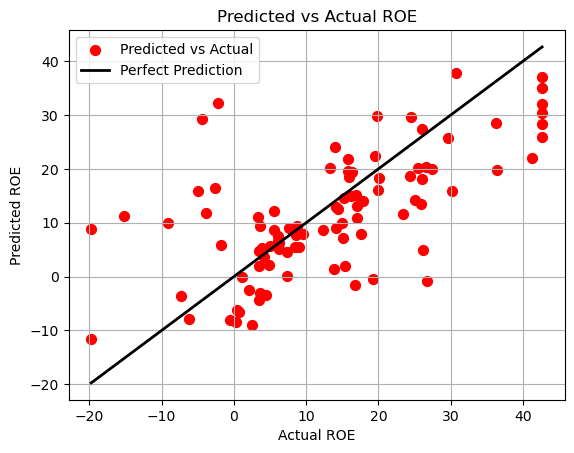

In [119]:
plt.scatter(y_test, y_pred_5, color='red', s=50, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='black', lw=2, label='Perfect Prediction')
plt.xlabel('Actual ROE')
plt.ylabel('Predicted ROE')
plt.title('Predicted vs Actual ROE')
plt.legend()
plt.grid(True)

In [121]:
print("R²:",r2_score(y_test,y_pred_5))
print("MAE:",mean_absolute_error(y_test,y_pred_5))
print("MSE:",mean_squared_error(y_test,y_pred_5))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_5)))

R²: 0.37955469433258104
MAE: 8.095135892478437
MSE: 121.42889831314785
RMSE: 11.019478132522785


### Linear Regression Model performed well as its r2_score is 80%

In [123]:
Company_name = str(input("Enter company name: "))
Last_Annual_EPS = float(input("Enter last annual EPS: "))
Return_on_Assets = float(input("Enter return on assets: "))
Last_annual_dividend = float(input("Enter last annual dividend: "))
Expected_dividend = float(input("Enter expected dividend: "))
Expected_ROE = float(input("Enter expected return on equity: "))
Latest_EPS = float(input("Enter latest EPS: "))

Enter company name:  Allied Bank Ltd.
Enter last annual EPS:  18.51
Enter return on assets:  0.94
Enter last annual dividend:  8.5
Enter expected dividend:  13.99
Enter expected return on equity:  22.43
Enter latest EPS:  15.23


In [125]:
c_encoder=LabelEncoder()
company_name_encoded=c_encoder.fit_transform([Company_name])[0]
x_new=[[company_name_encoded,Last_Annual_EPS,Return_on_Assets,Last_annual_dividend,Expected_dividend,Expected_ROE,Latest_EPS]]
scaler=StandardScaler()
x_new_scaled = scaler.fit_transform(x_new)

In [127]:
ROE_pred=model_3.predict(x_new_scaled)[0]

In [129]:
print(f"Predicted ROE of {Company_name} is {ROE_pred}")

Predicted ROE of Allied Bank Ltd. is 10.940763574660632
